In [1]:
import os
FIGURES_DIR = "../../../Results/Tessnim/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# 1. Load run-level metrics
csv_path = "../../../Results/Tessnim/all_subjects_yeo7_metrics.csv"
df = pd.read_csv(csv_path)

# Back-transform to r *before* grouping
df["segregation_r"] = np.tanh(df["segregation"])
df["integration_r"] = np.tanh(df["integration"])

# If normalized_segregation already exists in df, we just keep it
# (otherwise, comment it out from metrics list below)

level = "network"
group_cols = ["subject", "session", "run", "condition"]
if level == "network":
    group_cols += ["network"]

df_run = (
    df.groupby(group_cols, as_index=False)[
        ["segregation", "integration", "segregation_r", "integration_r", "normalized_segregation"]
    ].mean()
)

This cell compares the distribution of a metric (e.g. segregation) between Feedback and Transfer runs using a **bootstrapped, matched-size** approach:

1. **Extract raw values and sizes**  
   We take the metric values for feedback (`values_fb`) and transfer (`values_tr`), and store their sample sizes as `n_fb` and `n_tr`. This gives us the two distributions we want to compare.

2. **Define common histogram bins**  
   We set `bins = 40` and define `bin_edges` from the global min to the global max across both conditions. Using the same bin edges ensures that Feedback and Transfer histograms are directly comparable.

3. **Bootstrap matched-size feedback samples**  
   We perform `n_boot = 500` iterations. In each iteration:
   - We randomly select `n_tr` feedback values (without replacement) using `rng.choice`.
   - We compute a histogram for this subsample (`np.histogram`) using the fixed `bin_edges` and with `density=True` to obtain a probability density.
   - We accumulate the bin counts into `hist_fb_accum`.

4. **Average feedback histogram across bootstraps**  
   After all iterations, we divide `hist_fb_accum` by `n_boot` to obtain `hist_fb_mean`, which is the average density in each bin over many matched-size subsamples. This reduces the randomness that would come from plotting a single arbitrary subsample.

5. **Compute transfer histogram once**  
   For the Transfer condition, we compute a single histogram (`counts_tr`) using all `values_tr` and the same `bin_edges`. The resulting `counts_tr` is directly comparable to `hist_fb_mean`.

6. **Plot bootstrapped feedback vs transfer**  
   We compute `bin_centers` for visualization, then:
   - Plot `hist_fb_mean` as a smooth line for Feedback (bootstrapped, matched-size).
   - Plot `counts_tr` as a step histogram for Transfer.
   This shows how the typical feedback distribution would look if it had the same number of samples as the transfer condition, while reducing dependence on one particular random subsample.

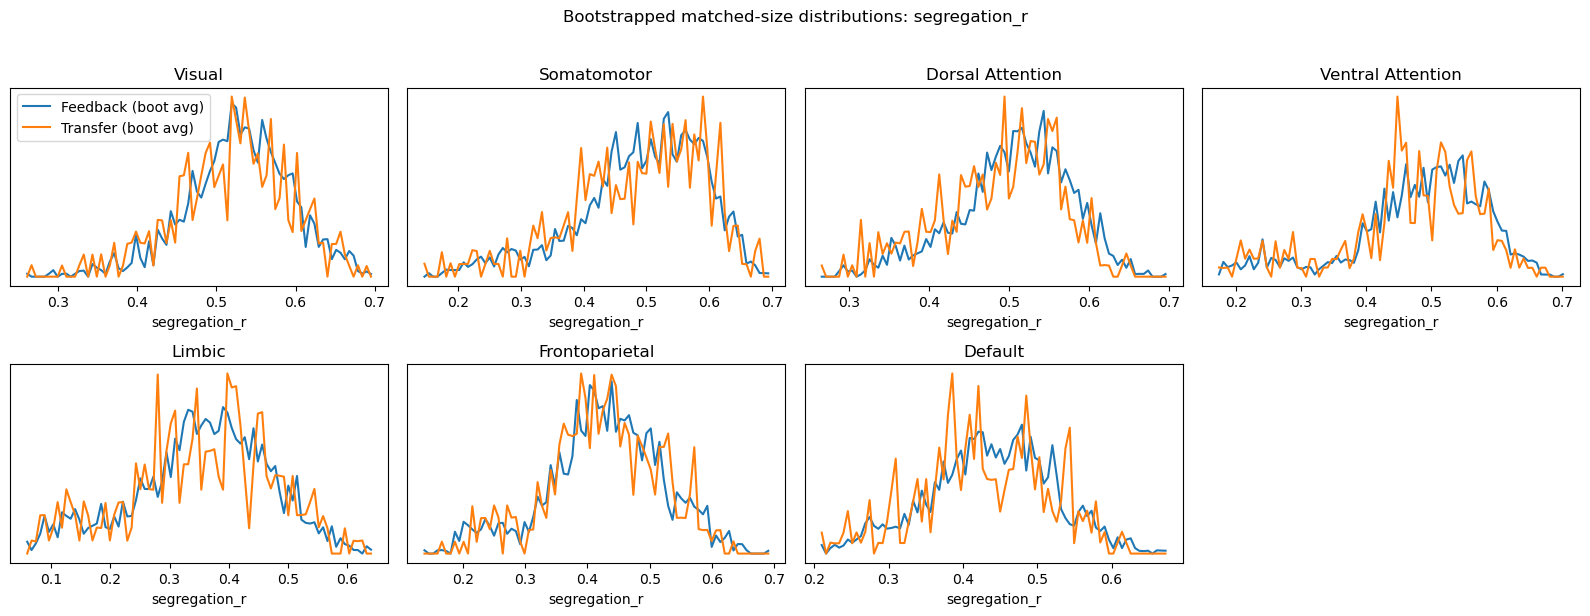

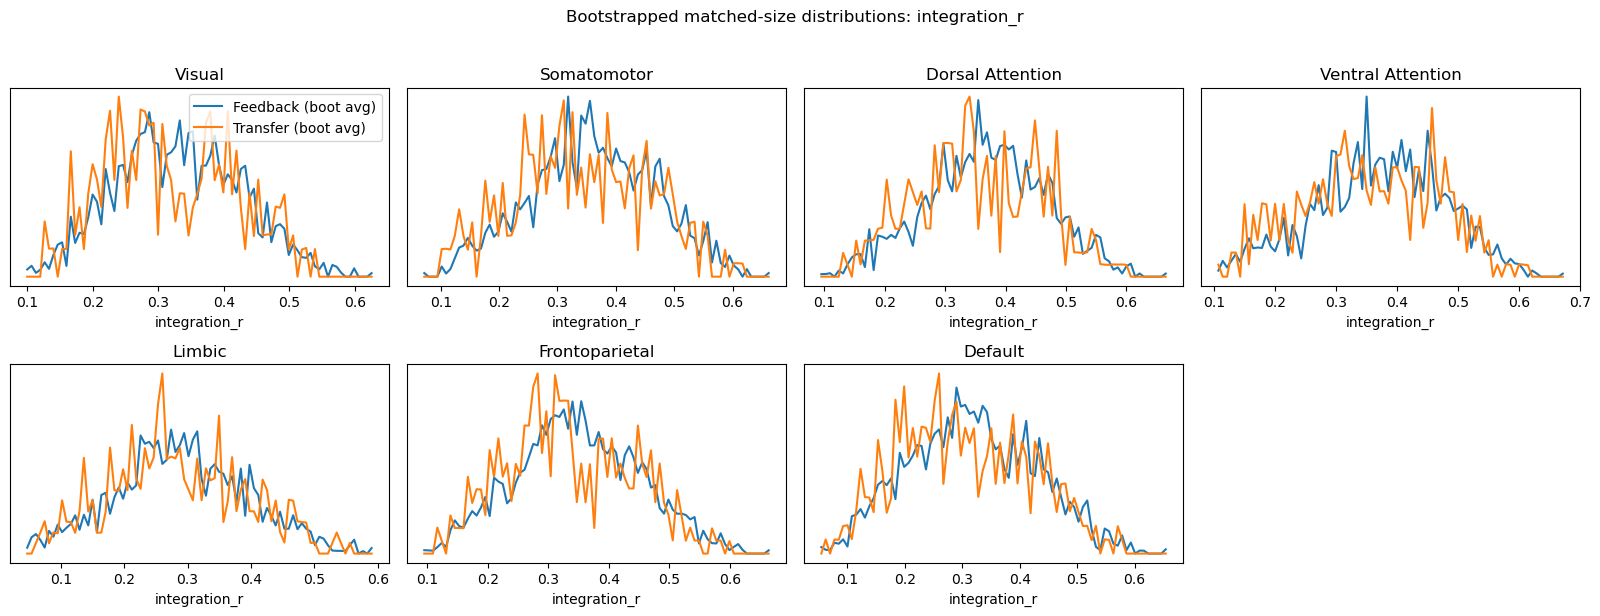

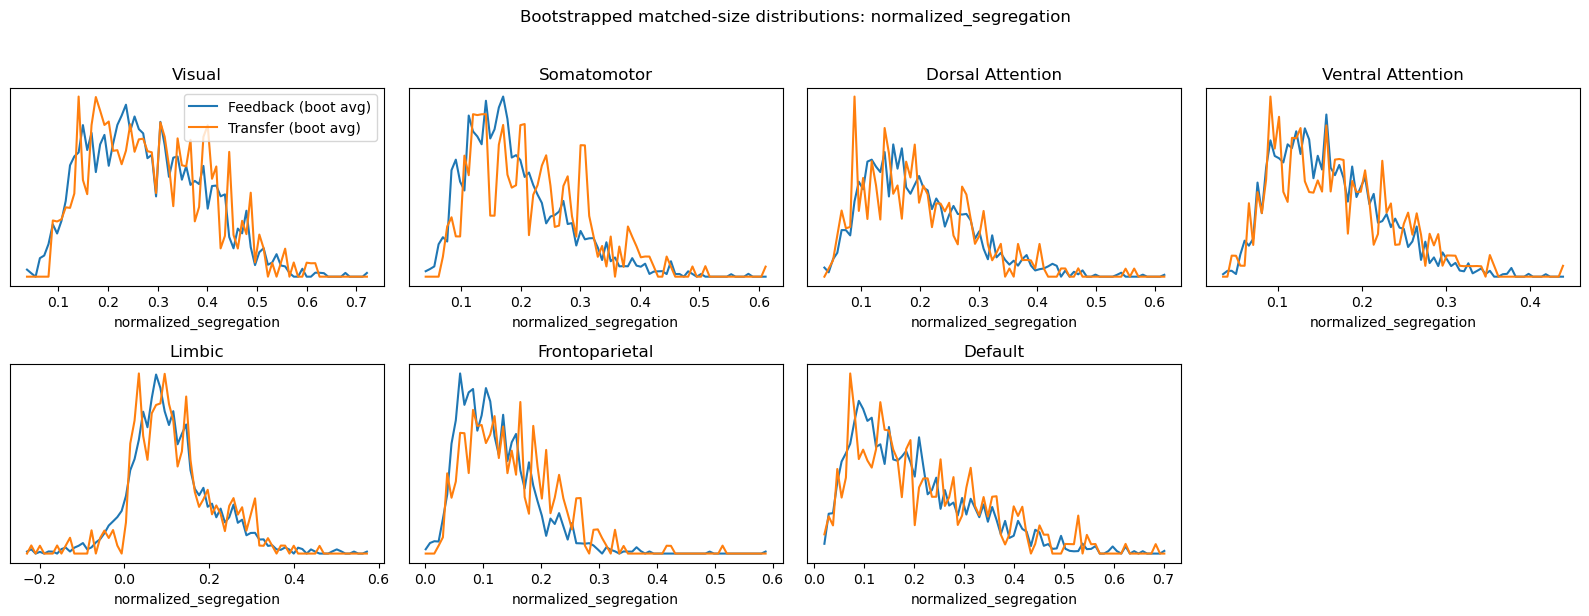

In [3]:
net_ids = sorted(df_run["network"].unique())  # e.g. [1..7]

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

bins = 80
n_boot = 500
rng = np.random.default_rng(42)

metrics = ["segregation_r", "integration_r", "normalized_segregation"]

for metric in metrics:
    n_cols = 4
    n_rows = int(np.ceil(len(net_ids) / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        squeeze=False
    )

    for i, net in enumerate(net_ids):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]

        df_net = df_run[df_run["network"] == net]
        fb = df_net[df_net["condition"] == "Feedback"]
        tr = df_net[df_net["condition"] == "Transfer"]

        values_fb = fb[metric].values
        values_tr = tr[metric].values

        if values_fb.size == 0 or values_tr.size == 0:
            ax.set_title(f"{YEO_NAMES[net-1]} (no data)")
            ax.axis("off")
            continue

        n_fb, n_tr = len(values_fb), len(values_tr)

        # choose common bootstrap sample size
        n_sample = min(300, n_fb, n_tr)  # or just min(n_fb, n_tr)

        vmin = min(values_fb.min(), values_tr.min())
        vmax = max(values_fb.max(), values_tr.max())
        bin_edges = np.linspace(vmin, vmax, bins + 1)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # accumulate bootstrapped histograms for both conditions
        hist_fb_accum = np.zeros(bins)
        hist_tr_accum = np.zeros(bins)

        for _ in range(n_boot):
            # sample same size from each condition
            idx_fb = rng.choice(n_fb, size=n_sample, replace=False)
            idx_tr = rng.choice(n_tr, size=n_sample, replace=False)

            sample_fb = values_fb[idx_fb]
            sample_tr = values_tr[idx_tr]

            counts_fb, _ = np.histogram(sample_fb, bins=bin_edges, density=True)
            counts_tr, _ = np.histogram(sample_tr, bins=bin_edges, density=True)

            hist_fb_accum += counts_fb
            hist_tr_accum += counts_tr

        hist_fb_mean = hist_fb_accum / n_boot
        hist_tr_mean = hist_tr_accum / n_boot

        ax.plot(bin_centers, hist_fb_mean, color="C0", label="Feedback (boot avg)")
        ax.plot(bin_centers, hist_tr_mean, color="C1", label="Transfer (boot avg)")

        ax.set_title(YEO_NAMES[net-1])
        ax.set_xlabel(metric)
        ax.yaxis.set_visible(False)
        if row == 0 and col == 0:
            ax.legend()

    for j in range(i + 1, n_rows * n_cols):
        row = j // n_cols
        col = j % n_cols
        axes[row, col].axis("off")

    fig.suptitle(f"Bootstrapped matched-size distributions: {metric}", y=1.02)
    plt.tight_layout()
    plt.show()

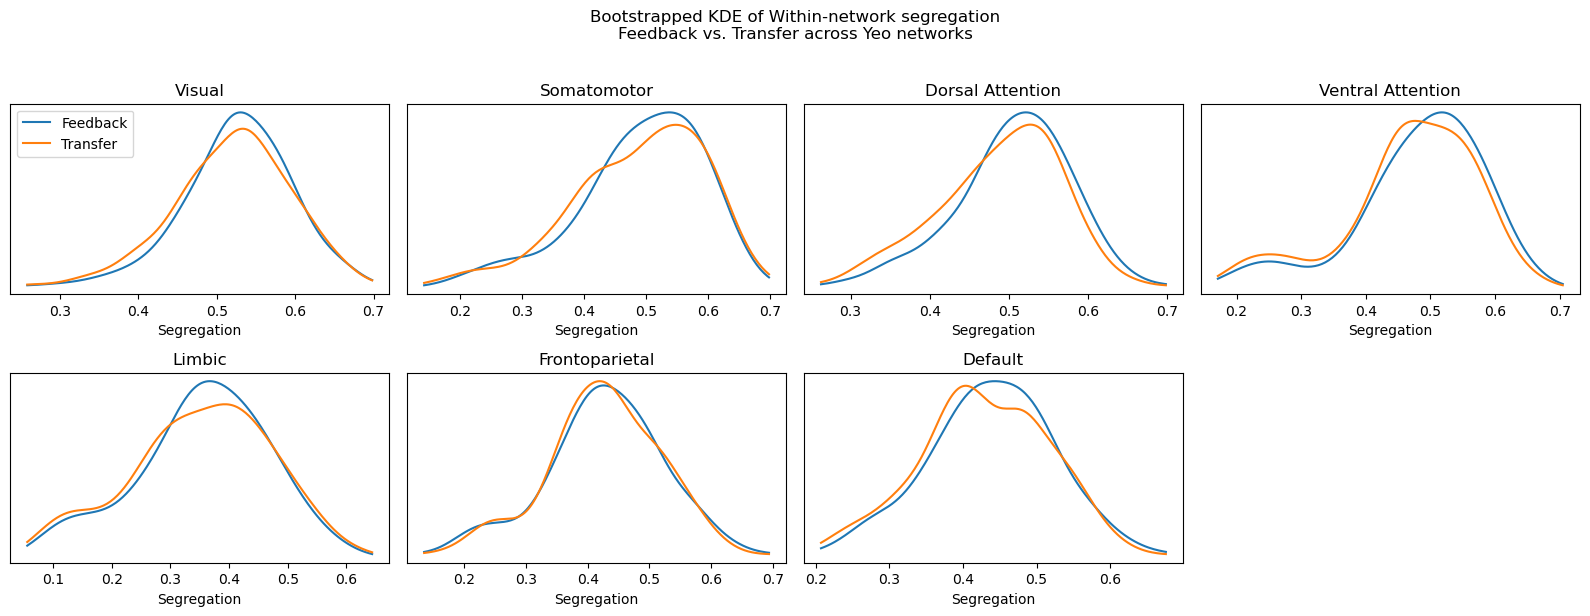

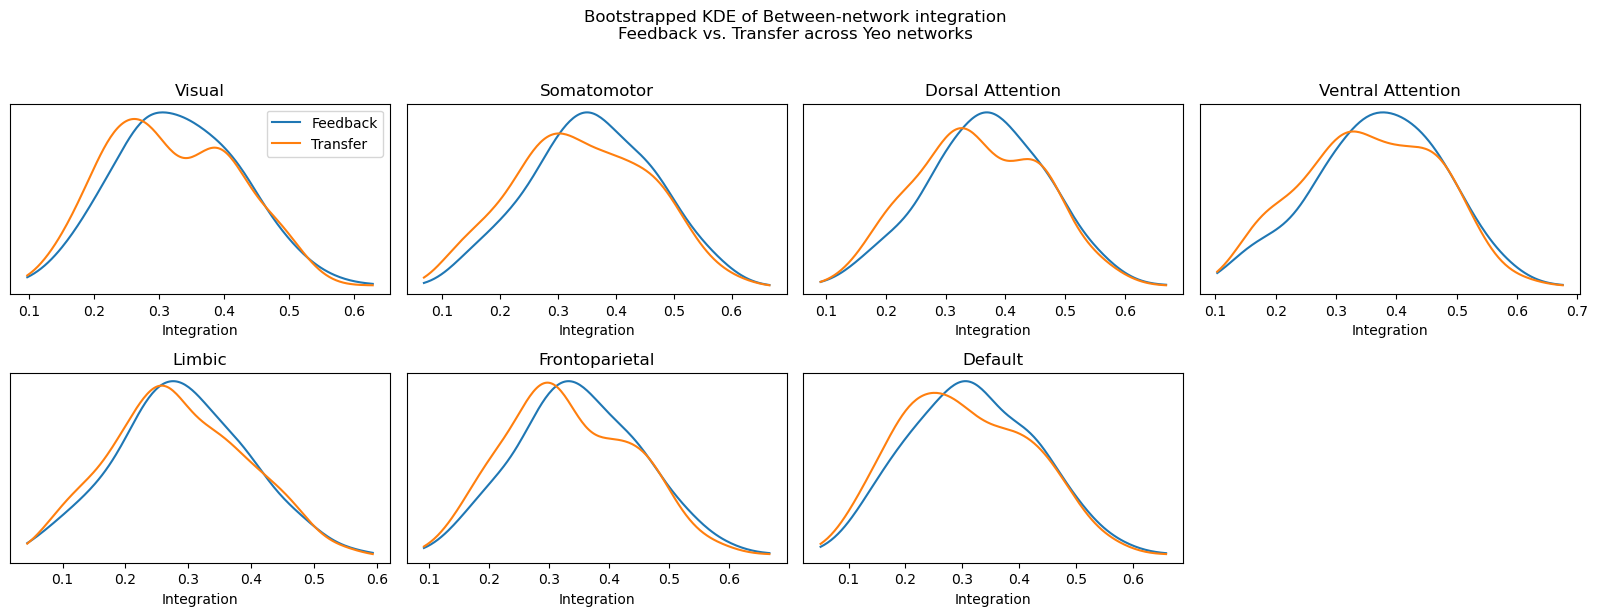

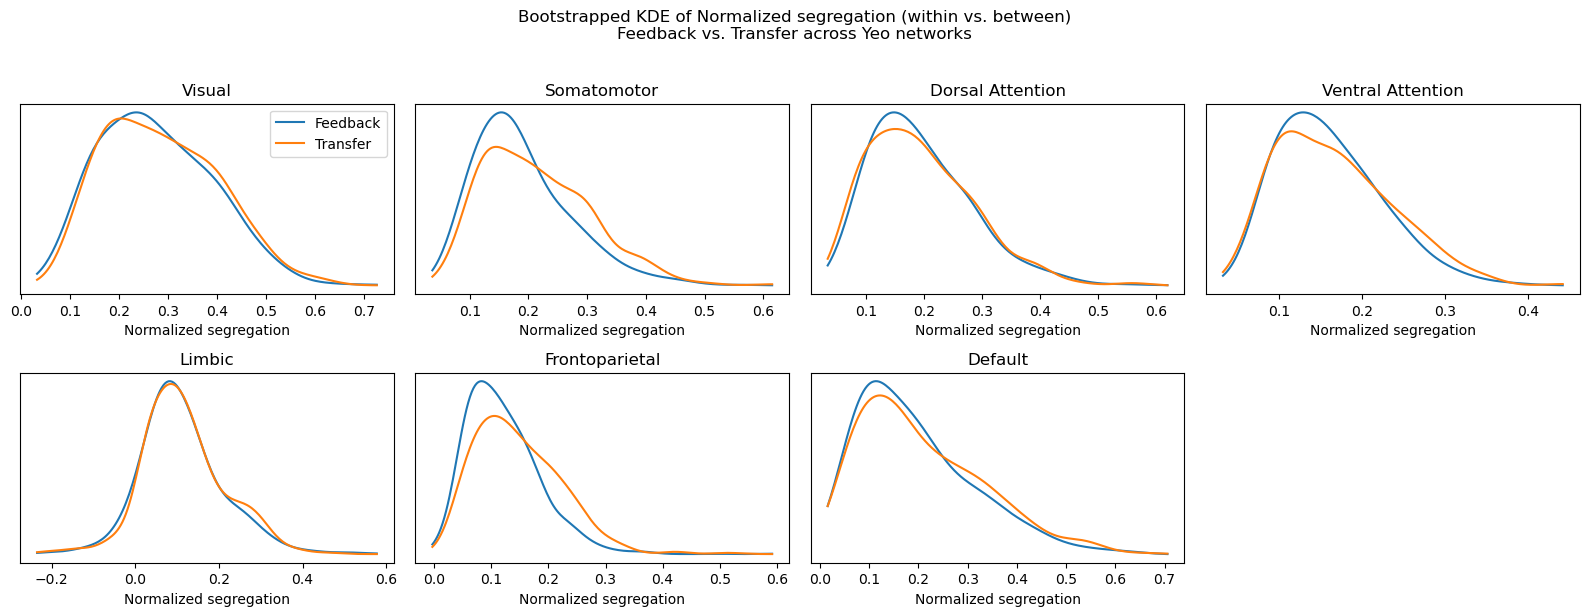

In [4]:
from scipy.stats import gaussian_kde  # add this import

net_ids = sorted(df_run["network"].unique())  # e.g. [1..7]

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

metrics = ["segregation_r", "integration_r", "normalized_segregation"]

metric_titles = {
    "segregation_r": "Within‑network segregation",
    "integration_r": "Between‑network integration",
    "normalized_segregation": "Normalized segregation (within vs. between)",
}
metric_xlabels = {
    "segregation_r": "Segregation",
    "integration_r": "Integration",
    "normalized_segregation": "Normalized segregation",
}

for metric in metrics:
    n_cols = 4
    n_rows = int(np.ceil(len(net_ids) / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        squeeze=False
    )

    for i, net in enumerate(net_ids):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]

        df_net = df_run[df_run["network"] == net]
        fb = df_net[df_net["condition"] == "Feedback"]
        tr = df_net[df_net["condition"] == "Transfer"]

        values_fb = fb[metric].values
        values_tr = tr[metric].values

        if values_fb.size < 5 or values_tr.size < 5:
            ax.set_title(f"{YEO_NAMES[net-1]} (too few samples)")
            ax.axis("off")
            continue

        n_fb, n_tr = len(values_fb), len(values_tr)
        n_sample = min(300, n_fb, n_tr)

        vmin = min(values_fb.min(), values_tr.min())
        vmax = max(values_fb.max(), values_tr.max())
        x_grid = np.linspace(vmin, vmax, 200)

        dens_fb_accum = np.zeros_like(x_grid)
        dens_tr_accum = np.zeros_like(x_grid)

        for _ in range(n_boot):
            idx_fb = rng.choice(n_fb, size=n_sample, replace=True)
            idx_tr = rng.choice(n_tr, size=n_sample, replace=True)

            sample_fb = values_fb[idx_fb]
            sample_tr = values_tr[idx_tr]

            kde_fb = gaussian_kde(sample_fb)
            kde_tr = gaussian_kde(sample_tr)

            dens_fb_accum += kde_fb(x_grid)
            dens_tr_accum += kde_tr(x_grid)

        dens_fb_mean = dens_fb_accum / n_boot
        dens_tr_mean = dens_tr_accum / n_boot

        ax.plot(x_grid, dens_fb_mean, color="C0", label="Feedback")
        ax.plot(x_grid, dens_tr_mean, color="C1", label="Transfer")

        # per‑network title
        ax.set_title(YEO_NAMES[net-1])

        # nicer x‑label based on metric
        ax.set_xlabel(metric_xlabels.get(metric, metric))
        ax.yaxis.set_visible(False)

        if row == 0 and col == 0:
            ax.legend()

    # turn off any unused axes
    for j in range(i + 1, n_rows * n_cols):
        row = j // n_cols
        col = j % n_cols
        axes[row, col].axis("off")

    # informative suptitle
    fig.suptitle(
        f"Bootstrapped KDE of {metric_titles.get(metric, metric)}\n"
        f"Feedback vs. Transfer across Yeo networks",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

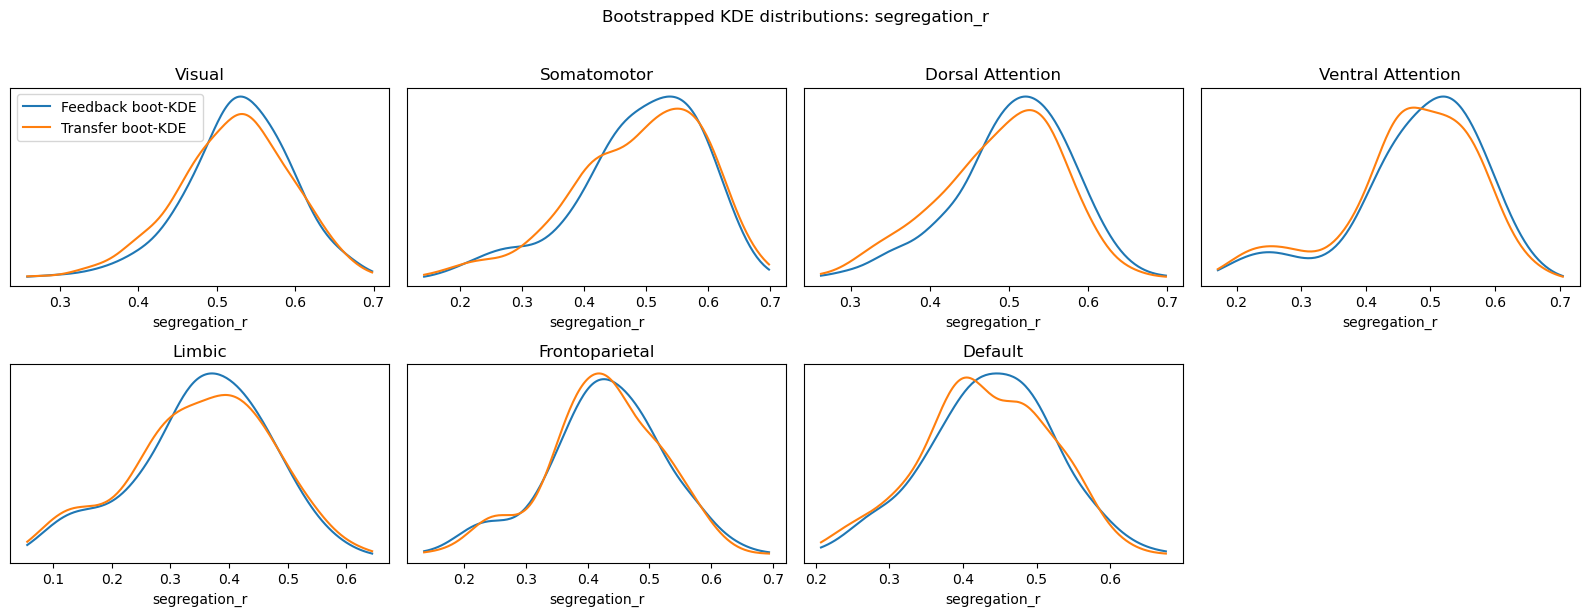

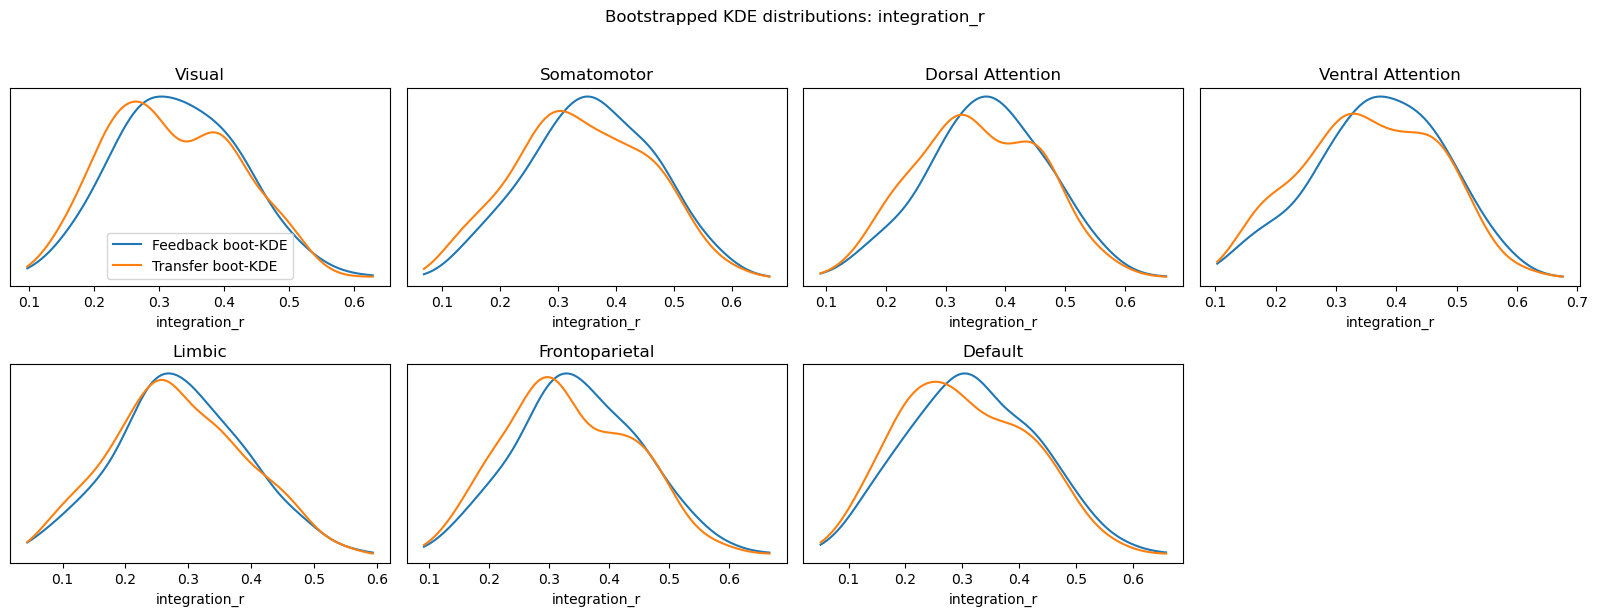

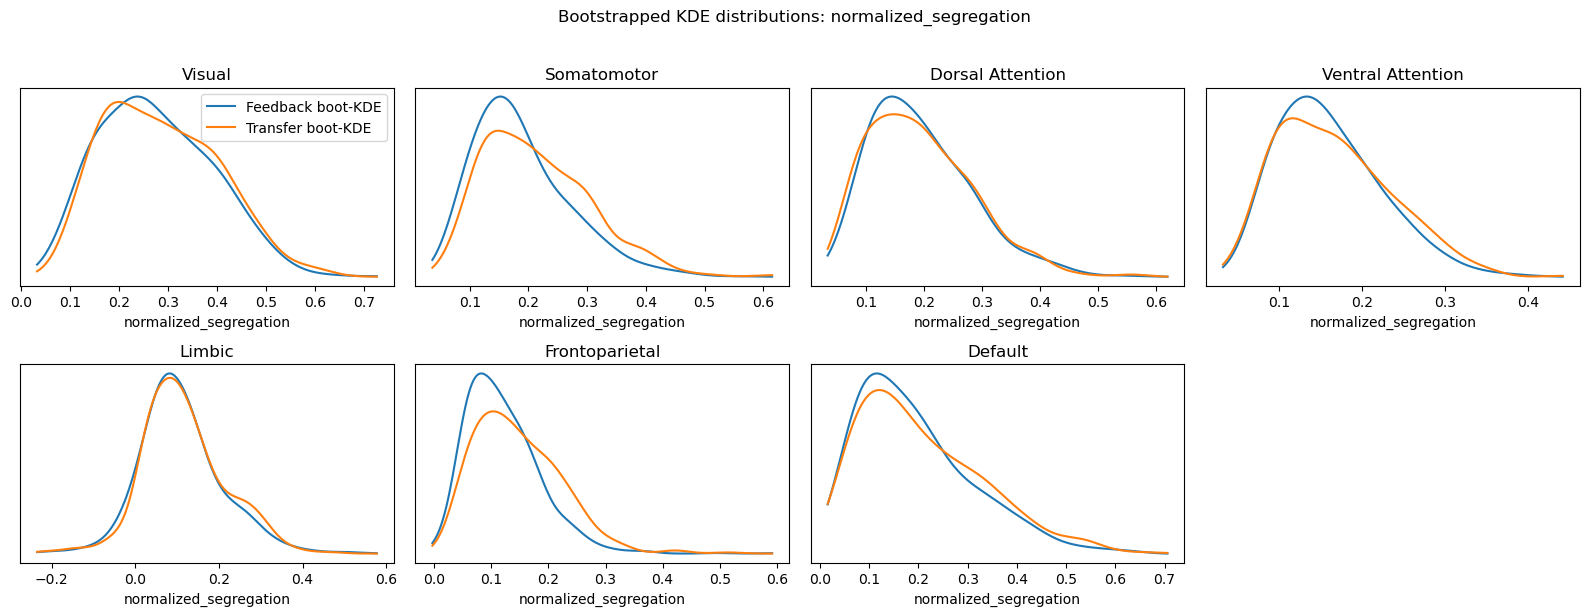

In [5]:
from scipy.stats import gaussian_kde

net_ids = sorted(df_run["network"].unique())

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

n_boot = 40
rng = np.random.default_rng(42)

metrics = ["segregation_r", "integration_r", "normalized_segregation"]

for metric in metrics:
    n_cols = 4
    n_rows = int(np.ceil(len(net_ids) / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        squeeze=False
    )

    for i, net in enumerate(net_ids):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]

        df_net = df_run[df_run["network"] == net]
        fb = df_net[df_net["condition"] == "Feedback"]
        tr = df_net[df_net["condition"] == "Transfer"]

        values_fb = fb[metric].values
        values_tr = tr[metric].values

        if values_fb.size < 5 or values_tr.size < 5:
            ax.set_title(f"{YEO_NAMES[net-1]} (too few samples)")
            ax.axis("off")
            continue

        n_fb, n_tr = len(values_fb), len(values_tr)
        n_sample = min(300, n_fb, n_tr)

        vmin = min(values_fb.min(), values_tr.min())
        vmax = max(values_fb.max(), values_tr.max())
        x_grid = np.linspace(vmin, vmax, 200)

        # accumulate bootstrapped KDE densities
        dens_fb_accum = np.zeros_like(x_grid)
        dens_tr_accum = np.zeros_like(x_grid)

        for _ in range(n_boot):
            idx_fb = rng.choice(n_fb, size=n_sample, replace=True)
            idx_tr = rng.choice(n_tr, size=n_sample, replace=True)

            sample_fb = values_fb[idx_fb]
            sample_tr = values_tr[idx_tr]

            kde_fb = gaussian_kde(sample_fb)
            kde_tr = gaussian_kde(sample_tr)

            dens_fb_accum += kde_fb(x_grid)
            dens_tr_accum += kde_tr(x_grid)

        dens_fb_mean = dens_fb_accum / n_boot
        dens_tr_mean = dens_tr_accum / n_boot

        ax.plot(x_grid, dens_fb_mean, color="C0", label="Feedback boot-KDE")
        ax.plot(x_grid, dens_tr_mean, color="C1", label="Transfer boot-KDE")

        ax.set_title(YEO_NAMES[net-1])
        ax.set_xlabel(metric)
        ax.yaxis.set_visible(False)

        if row == 0 and col == 0:
            ax.legend()

    for j in range(i + 1, n_rows * n_cols):
        row = j // n_cols
        col = j % n_cols
        axes[row, col].axis("off")

    fig.suptitle(f"Bootstrapped KDE distributions: {metric}", y=1.02)
    plt.tight_layout()
    plt.show()

This cell statistically compares the Feedback and Transfer distributions for one network and one metric:

1. **Select a network and extract values**  
   We choose a specific Yeo network (here `net = 1`, Visual) and subset `df_run` to that network. From this subset we pull the metric values (e.g. `segregation_r`, `integration_r`, or `normalized_segregation`) separately for Feedback (`fb`) and Transfer (`tr`) runs.

2. **Kolmogorov–Smirnov test (distributional difference)**  
   `stats.ks_2samp(fb, tr, ...)` performs a two‑sample Kolmogorov–Smirnov (K–S) test. It compares the entire empirical CDFs of Feedback and Transfer and returns:
   - `ks_stat`: the maximum vertical distance between the two CDFs.
   - `ks_p`: the p‑value for the null hypothesis that both samples are drawn from the same continuous distribution.

3. **Mann–Whitney U test (location difference)**  
   `stats.mannwhitneyu(fb, tr, ...)` performs a nonparametric test of whether the central tendency (median/location) differs between Feedback and Transfer. It returns:
   - `mw_stat`: the Mann–Whitney U statistic.
   - `mw_p`: the p‑value for the null hypothesis that the distributions have the same location (i.e. \(P(\text{fb} > \text{tr}) = 0.5\)).

4. **Printed summary**  
   The final `print` statements label the network and metric, then report both K–S and Mann–Whitney statistics and p‑values. Together, these tell us whether the two conditions differ in overall shape (K–S) and in central tendency (Mann–Whitney) for this network.

In [6]:
metrics = ["segregation_r", "integration_r", "normalized_segregation"]

rows = []

for metric in metrics:
    for net in net_ids:
        df_net = df_run[df_run["network"] == net]

        fb = df_net[df_net["condition"] == "Feedback"][metric].values
        tr = df_net[df_net["condition"] == "Transfer"][metric].values

        if fb.size == 0 or tr.size == 0:
            rows.append({
                "metric": metric,
                "network_id": net,
                "network_name": YEO_NAMES[net-1],
                "KS_stat": np.nan,
                "KS_p": np.nan,
                "MW_stat": np.nan,
                "MW_p": np.nan,
                "note": f"not enough data (fb={fb.size}, tr={tr.size})",
                "KS_sig": "",
                "MW_sig": "",
            })
            continue

        ks_stat, ks_p = stats.ks_2samp(fb, tr, alternative="two-sided", mode="auto")
        mw_stat, mw_p = stats.mannwhitneyu(fb, tr, alternative="two-sided")

        rows.append({
            "metric": metric,
            "network_id": net,
            "network_name": YEO_NAMES[net-1],
            "KS_stat": ks_stat,
            "KS_p": ks_p,
            "MW_stat": mw_stat,
            "MW_p": mw_p,
            "note": "",
            "KS_sig": "***" if ks_p < 0.001 else
                      "**"  if ks_p < 0.01  else
                      "*"   if ks_p < 0.05  else "",
            "MW_sig": "***" if mw_p < 0.001 else
                      "**"  if mw_p < 0.01  else
                      "*"   if mw_p < 0.05  else "",
        })

results_df = pd.DataFrame(rows)

# Nicely formatted p-values and flags
def fmt_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

results_df["KS_p_fmt"] = results_df["KS_p"].apply(fmt_p)
results_df["MW_p_fmt"] = results_df["MW_p"].apply(fmt_p)

# Choose column order for display
display_cols = [
    "metric", "network_id", "network_name",
    "KS_stat", "KS_p_fmt", "KS_sig",
    "MW_stat", "MW_p_fmt", "MW_sig",
    "note",
]

results_df_display = results_df[display_cols]

# Show full table (no truncation)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

results_df_display

,metric,network_id,network_name,KS_stat,KS_p_fmt,KS_sig,MW_stat,MW_p_fmt,MW_sig,note
0,segregation_r,1,Visual,0.074811,0.069,,280032.0,0.077,,
1,segregation_r,2,Somatomotor,0.071222,0.095,,270256.0,0.503,,
2,segregation_r,3,Dorsal Attention,0.108477,0.002,**,298305.0,<0.001,***,
3,segregation_r,4,Ventral Attention,0.091557,0.013,*,287916.0,0.008,**,
4,segregation_r,5,Limbic,0.056527,0.290,,268265.0,0.656,,
5,segregation_r,6,Frontoparietal,0.037619,0.781,,268435.0,0.642,,
6,segregation_r,7,Default,0.082631,0.033,*,280856.0,0.063,,
7,integration_r,1,Visual,0.096019,0.008,**,283109.0,0.034,*,
8,integration_r,2,Somatomotor,0.110107,0.001,**,289050.0,0.005,**,
9,integration_r,3,Dorsal Attention,0.109823,0.001,**,284874.0,0.021,*,


- **Kolmogorov–Smirnov (KS) test** (`ks_stat`, `ks_p`): tests whether the *entire* empirical distributions differ.  
  A large KS statistic and small p‑value indicate that Feedback and Transfer are unlikely to come from the same underlying distribution (differences in shape, spread, and/or location).

- **Mann–Whitney U test** (`mw_stat`, `mw_p`): tests whether one condition tends to produce systematically larger or smaller values than the other.  
  A small p‑value indicates a shift in **location** (e.g. median) between Feedback and Transfer, without assuming normality.

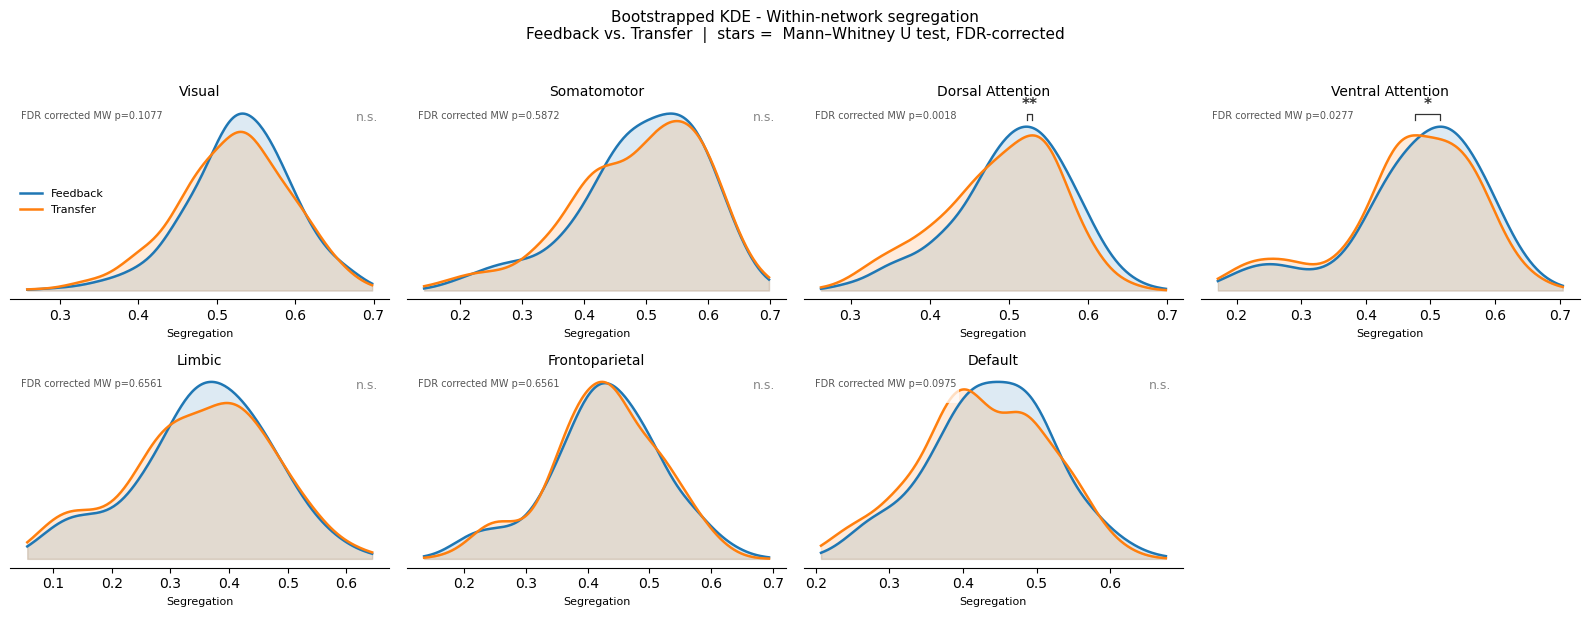

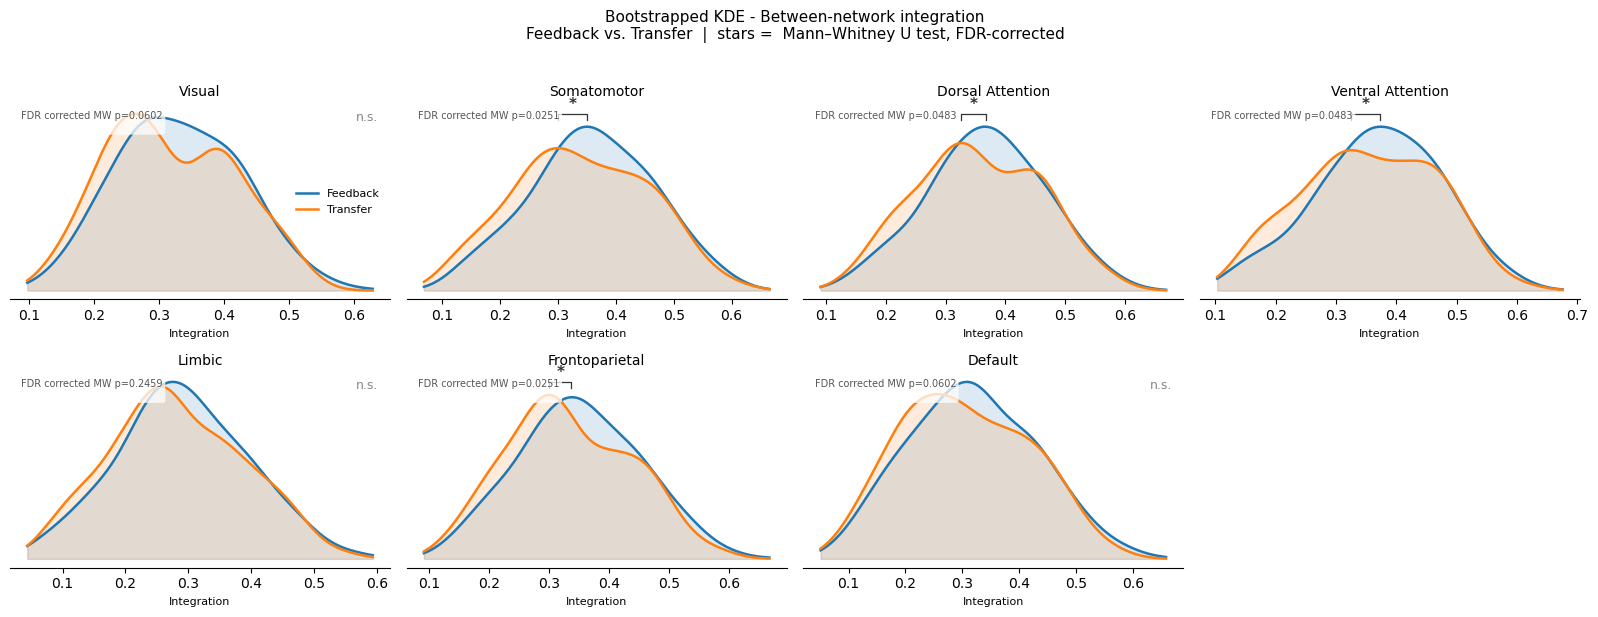

In [7]:
from scipy.stats import gaussian_kde, ks_2samp, mannwhitneyu
from statsmodels.stats.multitest import multipletests

net_ids   = sorted(df_run["network"].unique())
metrics   = ["segregation_r", "integration_r"]

YEO_NAMES = ["Visual", "Somatomotor", "Dorsal Attention",
             "Ventral Attention", "Limbic", "Frontoparietal", "Default"]

metric_titles = {
    "segregation_r":         "Within-network segregation",
    "integration_r":         "Between-network integration",
}
metric_xlabels = {
    "segregation_r":         "Segregation",
    "integration_r":         "Integration",
}

def p_to_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:            return "n.s."

# ════════════════════════════════════════════════════════════════════
# PASS 1 — collect raw KS p-values and precomputed KDE data
#           across ALL metrics × networks before any correction
# ════════════════════════════════════════════════════════════════════
keys      = []   # (metric, net) tuples — one per valid subplot
raw_mw    = []   # raw Mann-Whitney U p-values in the same order
kde_data  = {}   # (metric, net) → dict of arrays needed for plotting

for metric in metrics:
    for net in net_ids:
        df_net    = df_run[df_run["network"] == net]
        values_fb = df_net[df_net["condition"] == "Feedback"][metric].values
        values_tr = df_net[df_net["condition"] == "Transfer"][metric].values

        if values_fb.size < 5 or values_tr.size < 5:
            kde_data[(metric, net)] = None   # flag as skipped
            continue

        # significance on full data
        ks_stat, ks_p = ks_2samp(values_fb, values_tr, alternative="two-sided")
        mw_stat, mw_p = mannwhitneyu(values_fb, values_tr, alternative="two-sided")

        # bootstrap KDE smoothing
        n_fb, n_tr = len(values_fb), len(values_tr)
        n_sample   = min(300, n_fb, n_tr)
        vmin = min(values_fb.min(), values_tr.min())
        vmax = max(values_fb.max(), values_tr.max())
        x_grid = np.linspace(vmin, vmax, 200)

        dens_fb_accum = np.zeros_like(x_grid)
        dens_tr_accum = np.zeros_like(x_grid)
        for _ in range(n_boot):
            idx_fb = rng.choice(n_fb, size=n_sample, replace=True)
            idx_tr = rng.choice(n_tr, size=n_sample, replace=True)
            dens_fb_accum += gaussian_kde(values_fb[idx_fb])(x_grid)
            dens_tr_accum += gaussian_kde(values_tr[idx_tr])(x_grid)

        kde_data[(metric, net)] = {
            "x_grid":   x_grid,
            "dens_fb":  dens_fb_accum / n_boot,
            "dens_tr":  dens_tr_accum / n_boot,
            "ks_p_raw": ks_p,
            "mw_p_raw": mw_p,
        }
        keys.append((metric, net))
        raw_mw.append(mw_p)   # correct MW only (see note above)

# ════════════════════════════════════════════════════════════════════
# CORRECTION — BH applied once across all 21 valid tests
# ════════════════════════════════════════════════════════════════════
reject, p_corrected, _, _ = multipletests(raw_mw, method="fdr_bh")

# store corrected p back into kde_data for easy lookup during plotting
for (metric, net), p_corr, rej in zip(keys, p_corrected, reject):
    kde_data[(metric, net)]["mw_p_corr"] = p_corr
    kde_data[(metric, net)]["mw_reject"]  = rej

# ════════════════════════════════════════════════════════════════════
# PASS 2 — plot using corrected p-values
# ════════════════════════════════════════════════════════════════════
for metric in metrics:
    n_cols = 4
    n_rows = int(np.ceil(len(net_ids) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3 * n_rows),
                             squeeze=False)

    for i, net in enumerate(net_ids):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        d  = kde_data[(metric, net)]

        if d is None:
            ax.set_title(f"{YEO_NAMES[net-1]} (too few samples)")
            ax.axis("off")
            continue

        ax.plot(d["x_grid"], d["dens_fb"], color="C0", lw=1.8, label="Feedback")
        ax.plot(d["x_grid"], d["dens_tr"], color="C1", lw=1.8, label="Transfer")
        ax.fill_between(d["x_grid"], d["dens_fb"], alpha=0.15, color="C0")
        ax.fill_between(d["x_grid"], d["dens_tr"], alpha=0.15, color="C1")

        # significance bracket using corrected p
        mw_stars = p_to_stars(d["mw_p_corr"])
        y_top    = max(d["dens_fb"].max(), d["dens_tr"].max())

        if mw_stars != "n.s.":
            x_lo = d["x_grid"][np.argmax(d["dens_fb"])]
            x_hi = d["x_grid"][np.argmax(d["dens_tr"])]
            x_lo, x_hi = sorted([x_lo, x_hi])
            y_bar  = y_top * 1.08
            y_tick = y_top * 1.04
            ax.plot([x_lo, x_lo, x_hi, x_hi],
                    [y_tick, y_bar, y_bar, y_tick],
                    lw=0.9, color="#333")
            ax.text((x_lo + x_hi) / 2, y_bar * 1.01, mw_stars,
                    ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color="#333")
        else:
            ax.text(0.97, 0.97, "n.s.",
                    transform=ax.transAxes,
                    ha="right", va="top",
                    fontsize=9, color="#888")

        # compact p-value box: both raw and corrected for transparency
        p_txt = (
            f"FDR corrected MW p={d['mw_p_corr']:.4f}\n"
        )
        ax.text(0.03, 0.97, p_txt,
                transform=ax.transAxes,
                ha="left", va="top", fontsize=7, color="#555",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", alpha=0.75,
                          edgecolor="none"))

        ax.set_title(YEO_NAMES[net - 1], fontsize=10)
        ax.set_xlabel(metric_xlabels.get(metric, metric), fontsize=8)
        ax.yaxis.set_visible(False)
        ax.spines[["top", "left", "right"]].set_visible(False)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, frameon=False)

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")

    fig.suptitle(
        f"Bootstrapped KDE - {metric_titles.get(metric, metric)}\n"
        "Feedback vs. Transfer  |  stars =  Mann–Whitney U test, FDR-corrected",
        y=1.02, fontsize=11
    )
    plt.tight_layout()
    plt.show()

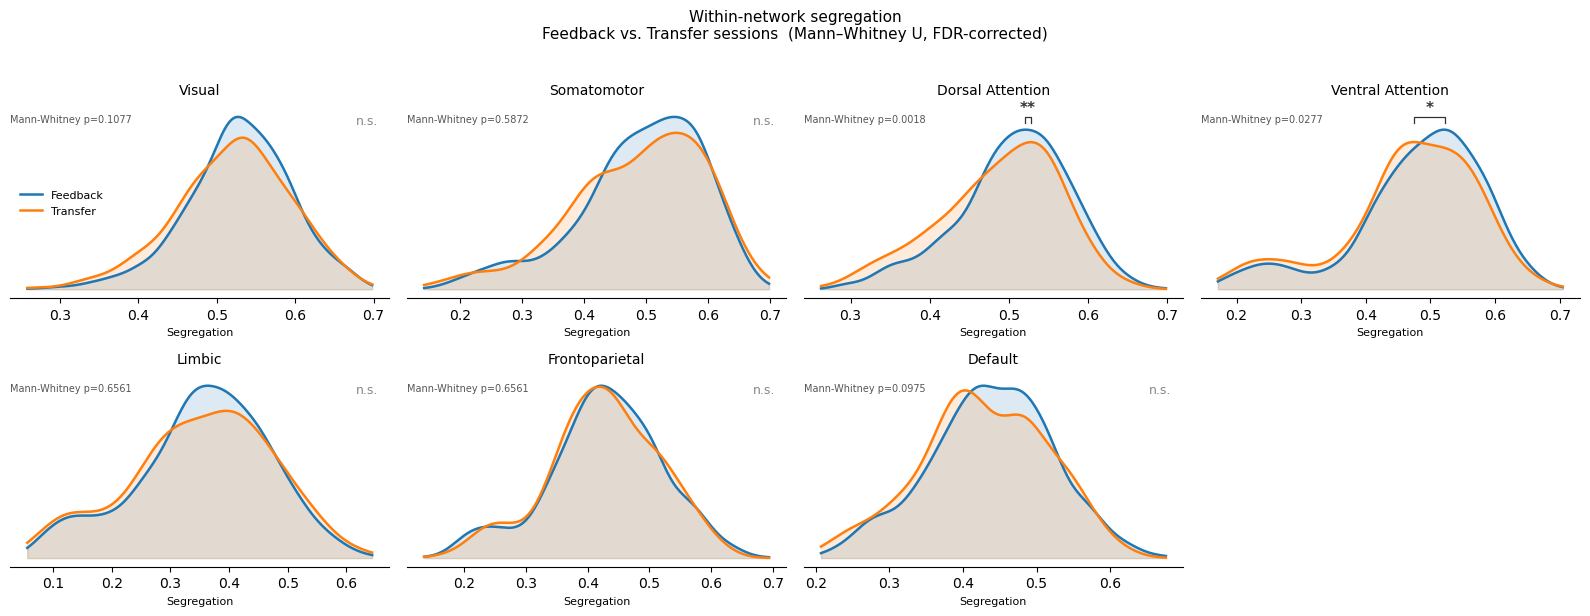

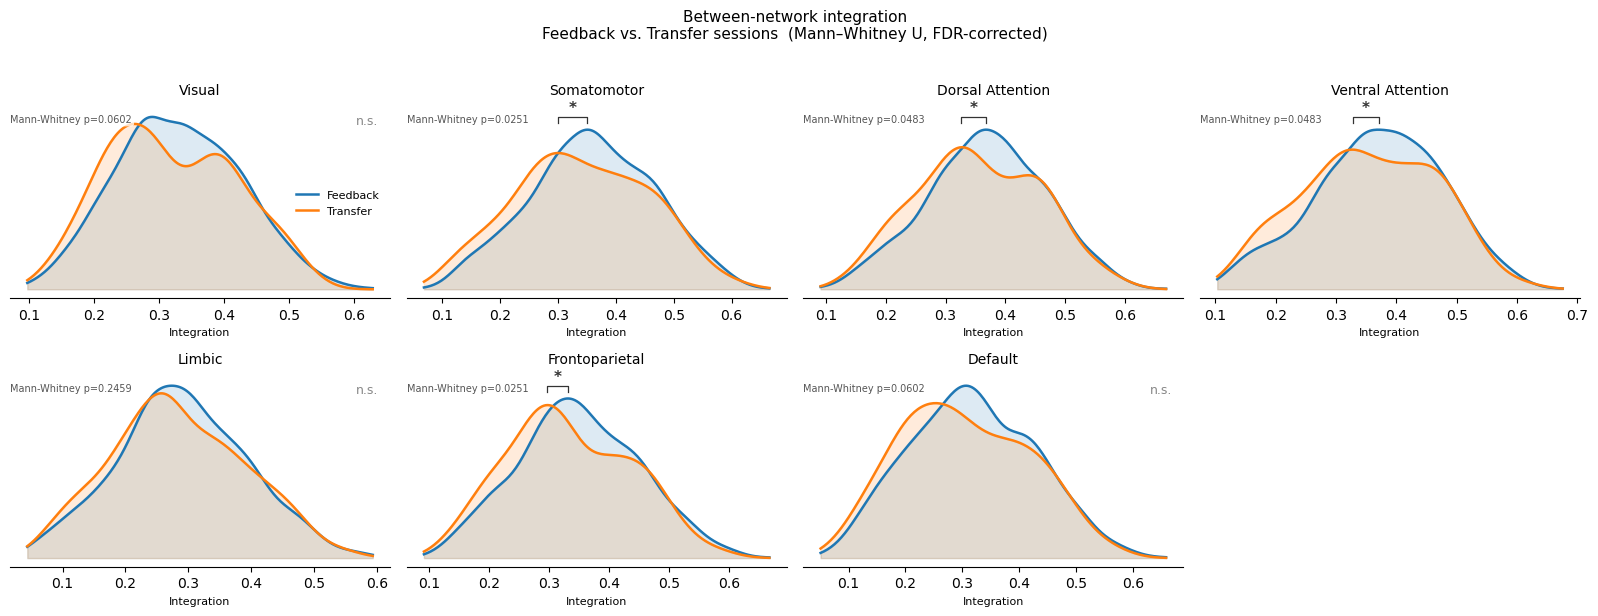

In [8]:
from scipy.stats import gaussian_kde, mannwhitneyu
from statsmodels.stats.multitest import multipletests

net_ids   = sorted(df_run["network"].unique())
metrics   = ["segregation_r", "integration_r"]

YEO_NAMES = ["Visual", "Somatomotor", "Dorsal Attention",
             "Ventral Attention", "Limbic", "Frontoparietal", "Default"]

metric_titles = {
    "segregation_r": "Within-network segregation",
    "integration_r": "Between-network integration",
}
metric_xlabels = {
    "segregation_r": "Segregation",
    "integration_r": "Integration",
}

def p_to_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:            return "n.s."

# ════════════════════════════════════════════════════════════════
# PASS 1 — fit KDE on full data + collect raw MW p-values
# ════════════════════════════════════════════════════════════════
keys     = []
raw_mw   = []
kde_data = {}

for metric in metrics:
    for net in net_ids:
        df_net    = df_run[df_run["network"] == net]
        values_fb = df_net[df_net["condition"] == "Feedback"][metric].values
        values_tr = df_net[df_net["condition"] == "Transfer"][metric].values

        if values_fb.size < 5 or values_tr.size < 5:
            kde_data[(metric, net)] = None
            continue

        # significance on full data
        _, mw_p = mannwhitneyu(values_fb, values_tr, alternative="two-sided")

        # KDE fitted directly on full data — no bootstrap loop
        vmin   = min(values_fb.min(), values_tr.min())
        vmax   = max(values_fb.max(), values_tr.max())
        x_grid = np.linspace(vmin, vmax, 200)

        dens_fb = gaussian_kde(values_fb)(x_grid)
        dens_tr = gaussian_kde(values_tr)(x_grid)

        kde_data[(metric, net)] = {
            "x_grid":   x_grid,
            "dens_fb":  dens_fb,
            "dens_tr":  dens_tr,
            "mw_p_raw": mw_p,
        }
        keys.append((metric, net))
        raw_mw.append(mw_p)

# ════════════════════════════════════════════════════════════════
# CORRECTION — BH across all valid tests
# ════════════════════════════════════════════════════════════════
reject, p_corrected, _, _ = multipletests(raw_mw, method="fdr_bh")

for (metric, net), p_corr, rej in zip(keys, p_corrected, reject):
    kde_data[(metric, net)]["mw_p_corr"] = p_corr
    kde_data[(metric, net)]["mw_reject"]  = rej

# ════════════════════════════════════════════════════════════════
# PASS 2 — plot
# ════════════════════════════════════════════════════════════════
for metric in metrics:
    n_cols = 4
    n_rows = int(np.ceil(len(net_ids) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3 * n_rows),
                             squeeze=False)

    for i, net in enumerate(net_ids):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        d  = kde_data[(metric, net)]

        if d is None:
            ax.set_title(f"{YEO_NAMES[net-1]} (too few samples)")
            ax.axis("off")
            continue

        ax.plot(d["x_grid"], d["dens_fb"], color="C0", lw=1.8, label="Feedback")
        ax.plot(d["x_grid"], d["dens_tr"], color="C1", lw=1.8, label="Transfer")
        ax.fill_between(d["x_grid"], d["dens_fb"], alpha=0.15, color="C0")
        ax.fill_between(d["x_grid"], d["dens_tr"], alpha=0.15, color="C1")

        mw_stars = p_to_stars(d["mw_p_corr"])
        y_top    = max(d["dens_fb"].max(), d["dens_tr"].max())

        if mw_stars != "n.s.":
            x_lo = d["x_grid"][np.argmax(d["dens_fb"])]
            x_hi = d["x_grid"][np.argmax(d["dens_tr"])]
            x_lo, x_hi = sorted([x_lo, x_hi])
            y_bar  = y_top * 1.08
            y_tick = y_top * 1.04
            ax.plot([x_lo, x_lo, x_hi, x_hi],
                    [y_tick, y_bar, y_bar, y_tick],
                    lw=0.9, color="#333")
            ax.text((x_lo + x_hi) / 2, y_bar * 1.01, mw_stars,
                    ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color="#333")
        else:
            ax.text(0.97, 0.97, "n.s.",
                    transform=ax.transAxes,
                    ha="right", va="top",
                    fontsize=9, color="#888")

        ax.text(0, 0.97,
                f"Mann-Whitney p={d['mw_p_corr']:.4f}",
                transform=ax.transAxes,
                ha="left", va="top", fontsize=7, color="#555",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", alpha=0.75,
                          edgecolor="none"))

        ax.set_title(YEO_NAMES[net - 1], fontsize=10, pad=10)
        ax.set_xlabel(metric_xlabels.get(metric, metric), fontsize=8)
        ax.yaxis.set_visible(False)
        ax.spines[["top", "left", "right"]].set_visible(False)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, frameon=False)

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")

    fig.suptitle(
        f"{metric_titles.get(metric, metric)}\nFeedback vs. Transfer sessions  (Mann–Whitney U, FDR-corrected)",
        y=1.02, fontsize=11
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"kde_{metric}_feedback_vs_transfer.png"), bbox_inches="tight", dpi=300)
    plt.show()

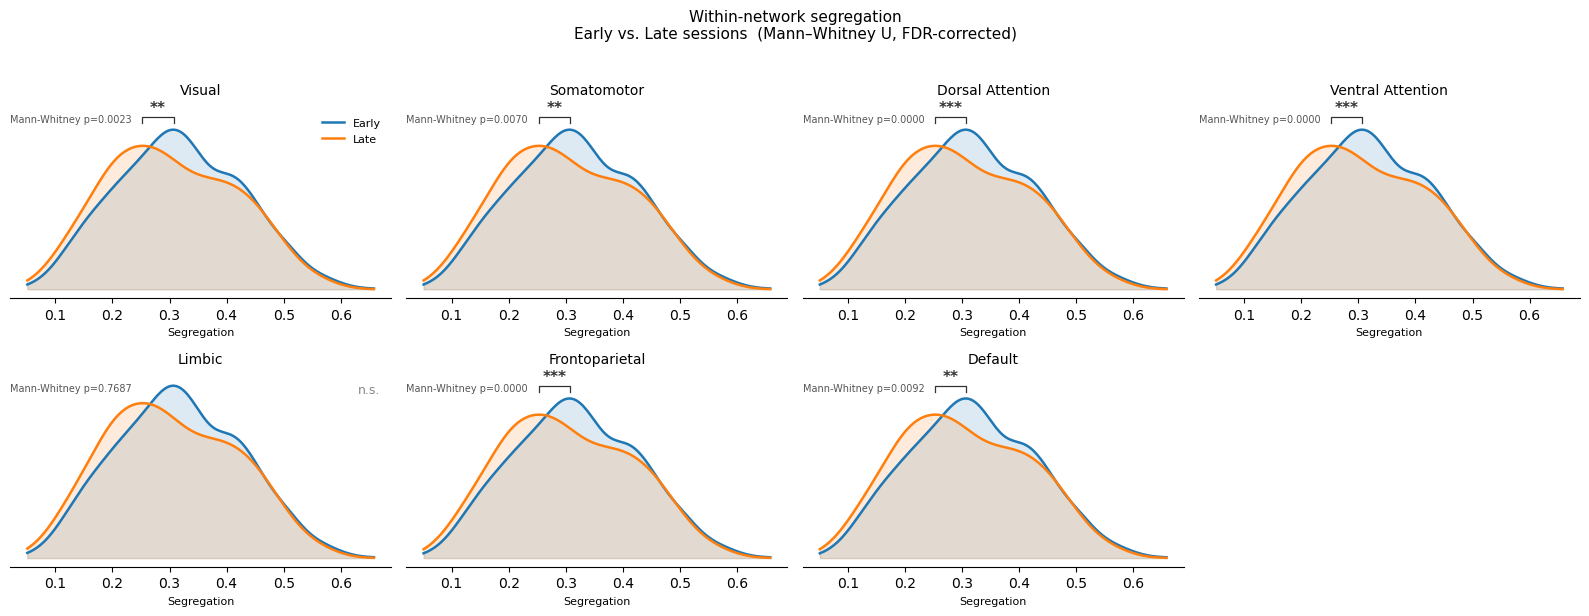

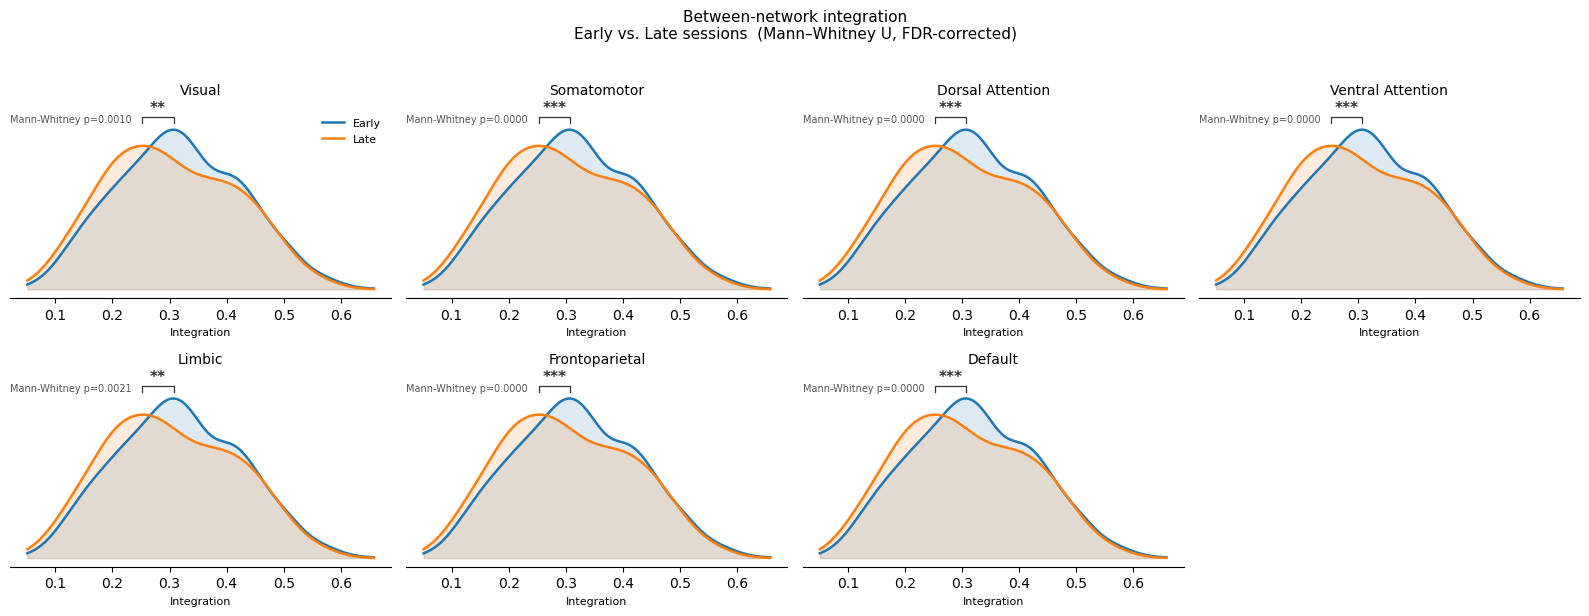

In [9]:
from scipy.stats import gaussian_kde, mannwhitneyu
from statsmodels.stats.multitest import multipletests

net_ids   = sorted(df_run["network"].unique())
metrics   = ["segregation_r", "integration_r"]

YEO_NAMES = ["Visual", "Somatomotor", "Dorsal Attention",
             "Ventral Attention", "Limbic", "Frontoparietal", "Default"]

metric_titles = {
    "segregation_r": "Within-network segregation",
    "integration_r": "Between-network integration",
}
metric_xlabels = {
    "segregation_r": "Segregation",
    "integration_r": "Integration",
}

def p_to_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:            return "n.s."

# ════════════════════════════════════════════════════════════════
# PASS 1 — fit KDE on full data + collect raw MW p-values
# ════════════════════════════════════════════════════════════════
keys     = []
raw_mw   = []
kde_data = {}

early_sessions = ["V01", "V02", "V03", "V04", "V05"]
late_sessions  = ["V11","V12","V13","V14", "V15"]


for metric in metrics:
    for net in net_ids:
        df_net    = df_run[df_run["network"] == net]
        values_early = df_net[df_net["session"].isin(early_sessions)][metric].values
        values_late  = df_net[df_net["session"].isin(late_sessions)][metric].values

        if values_fb.size < 5 or values_tr.size < 5:
            kde_data[(metric, net)] = None
            continue

        # significance on full data
        _, mw_p = mannwhitneyu(values_early, values_late, alternative="two-sided")

        # KDE fitted directly on full data — no bootstrap loop
        vmin   = min(values_fb.min(), values_tr.min())
        vmax   = max(values_fb.max(), values_tr.max())
        x_grid = np.linspace(vmin, vmax, 200)

        dens_fb = gaussian_kde(values_fb)(x_grid)
        dens_tr = gaussian_kde(values_tr)(x_grid)

        kde_data[(metric, net)] = {
            "x_grid":   x_grid,
            "dens_fb":  dens_fb,
            "dens_tr":  dens_tr,
            "mw_p_raw": mw_p,
        }
        keys.append((metric, net))
        raw_mw.append(mw_p)

# ════════════════════════════════════════════════════════════════
# CORRECTION — BH across all valid tests
# ════════════════════════════════════════════════════════════════
reject, p_corrected, _, _ = multipletests(raw_mw, method="fdr_bh")

for (metric, net), p_corr, rej in zip(keys, p_corrected, reject):
    kde_data[(metric, net)]["mw_p_corr"] = p_corr
    kde_data[(metric, net)]["mw_reject"]  = rej

# ════════════════════════════════════════════════════════════════
# PASS 2 — plot
# ════════════════════════════════════════════════════════════════
for metric in metrics:
    n_cols = 4
    n_rows = int(np.ceil(len(net_ids) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3 * n_rows),
                             squeeze=False)

    for i, net in enumerate(net_ids):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        d  = kde_data[(metric, net)]

        if d is None:
            ax.set_title(f"{YEO_NAMES[net-1]} (too few samples)")
            ax.axis("off")
            continue

        ax.plot(d["x_grid"], d["dens_fb"], color="C0", lw=1.8, label="Early")
        ax.plot(d["x_grid"], d["dens_tr"], color="C1", lw=1.8, label="Late")
        ax.fill_between(d["x_grid"], d["dens_fb"], alpha=0.15, color="C0")
        ax.fill_between(d["x_grid"], d["dens_tr"], alpha=0.15, color="C1")

        mw_stars = p_to_stars(d["mw_p_corr"])
        y_top    = max(d["dens_fb"].max(), d["dens_tr"].max())

        if mw_stars != "n.s.":
            x_lo = d["x_grid"][np.argmax(d["dens_fb"])]
            x_hi = d["x_grid"][np.argmax(d["dens_tr"])]
            x_lo, x_hi = sorted([x_lo, x_hi])
            y_bar  = y_top * 1.08
            y_tick = y_top * 1.04
            ax.plot([x_lo, x_lo, x_hi, x_hi],
                    [y_tick, y_bar, y_bar, y_tick],
                    lw=0.9, color="#333")
            ax.text((x_lo + x_hi) / 2, y_bar * 1.01, mw_stars,
                    ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color="#333")
        else:
            ax.text(0.97, 0.97, "n.s.",
                    transform=ax.transAxes,
                    ha="right", va="top",
                    fontsize=9, color="#888")

        ax.text(0, 0.97,
                f"Mann-Whitney p={d['mw_p_corr']:.4f}",
                transform=ax.transAxes,
                ha="left", va="top", fontsize=7, color="#555",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", alpha=0.75,
                          edgecolor="none"))

        ax.set_title(YEO_NAMES[net - 1], fontsize=10, pad=10)
        ax.set_xlabel(metric_xlabels.get(metric, metric), fontsize=8)
        ax.yaxis.set_visible(False)
        ax.spines[["top", "left", "right"]].set_visible(False)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, frameon=False)

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")

    fig.suptitle(
        f"{metric_titles.get(metric, metric)}\nEarly vs. Late sessions  (Mann–Whitney U, FDR-corrected)",
        y=1.02, fontsize=11
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"kde_{metric}_early_vs_late.png"), bbox_inches="tight", dpi=300)
    plt.show()